In [97]:
import sys
import os

# Add parent directory to path
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = os.path.dirname(notebook_dir)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.dataset import PINNDataset

print('✓ Modules loaded')
print('\nAvailable configs:')
print('  - ../configs/baseline.yaml (Calhoun CCZO, 6 depths)')
print('  - ../configs/us_ton_2023.yaml')

✓ Modules loaded

Available configs:
  - ../configs/baseline.yaml (Calhoun CCZO, 6 depths)
  - ../configs/us_ton_2023.yaml


In [98]:
# Choose your config file:
config_file = '../configs/us_ona_2022.yaml'   

print('='*70)
print('LOADING DATASET FROM YAML')
print('='*70)
print(f'Config: {config_file}\n')

# Load everything with one line!
dataset = PINNDataset(config_file, verbose=True)

print('\n' + '='*70)
print('DATASET LOADED SUCCESSFULLY')
print('='*70)

LOADING DATASET FROM YAML
Config: ../configs/us_ona_2022.yaml

INITIALIZING PINN DATASET
Config: ../configs/us_ona_2022.yaml
Note: Adjusted data path for notebook context: ../data/AMF_US-ONA_BASE_HH_4-5.csv


LOADING DATA FROM YAML SPECIFICATION
LOADING SOIL MOISTURE DATA (GENERIC LOADER)
  File format: CSV

Data loaded:
  Total records: 122735
  Time range: 2016-01-01 00:00:00 to 2022-12-31 23:00:00
  Duration: ~2556 days
  Resolution: 30 minutes

REPLACING MISSING VALUE CODES (-9999, -6999, +9999) WITH NaN
Missing value codes replaced with NaN
Unit conversion applied: ×0.01

Time period selection (date-based):
  Start date: 2022-01-01 00:00:00
  End date:   2022-12-31 00:00:00
  Selected:   17473 points
  Date range: 2022-01-01 00:00:00 to 2022-12-31 00:00:00
  Duration:   364.0 days

Raw data quality (after replacing missing codes with NaN):
----------------------------------------------------------------------
10cm  : 16852 valid,   621 NaN ( 3.55%), range=[0.0006, 0.3972]
20cm  : 

PLOTTING ALL OBSERVATION DEPTHS


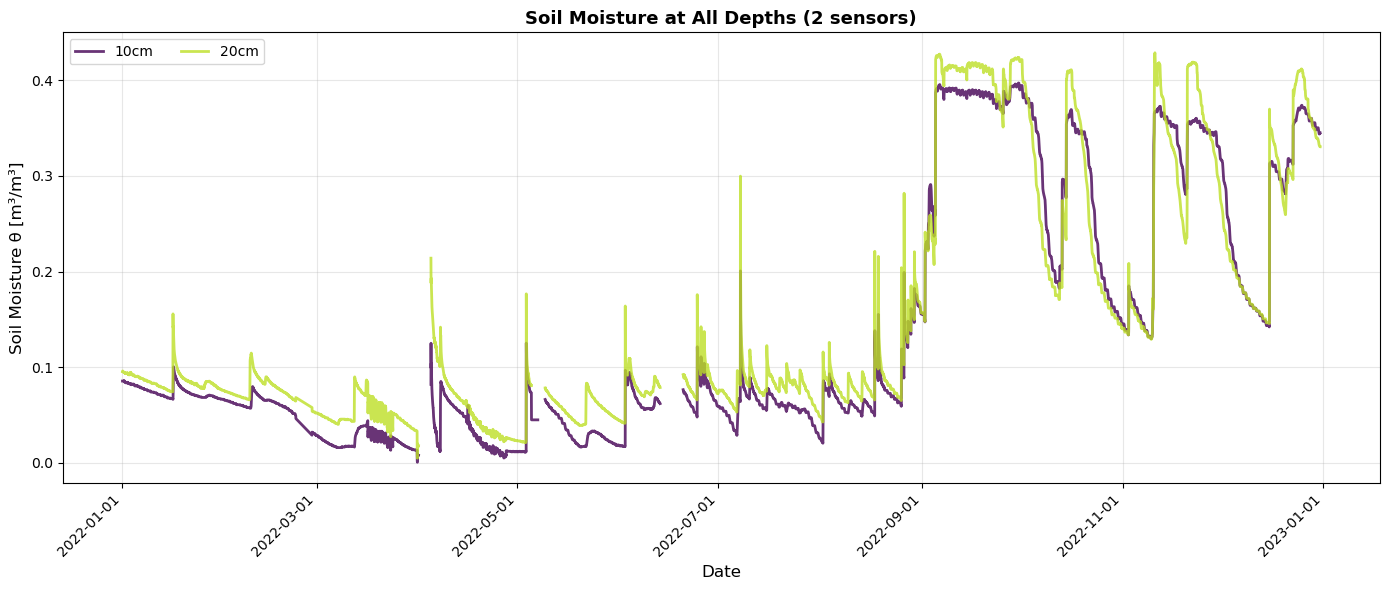


✓ Plotted 2 observation depths
   10cm: 16852/17473 valid ( 96.4%)
   20cm: 16758/17473 valid ( 95.9%)


In [99]:
print('='*70)
print('PLOTTING ALL OBSERVATION DEPTHS')
print('='*70)

obs_data = dataset.get_obs_data_for_viz()
obs_times = obs_data['times']  # Time in seconds
obs_depths = obs_data['depths']  # List of depths in meters (negative)
obs_theta_series = obs_data['theta']  # List of theta arrays

# Convert time to days for plotting
t_days = obs_times / 86400.0

# Convert to datetime for nicer x-axis
from datetime import datetime, timedelta
start_datetime = datetime.strptime(dataset.config.start_date, '%Y-%m-%d')
datetimes = [start_datetime + timedelta(seconds=float(t)) for t in obs_times]

# Create figure
n_depths = len(obs_depths)
colors = plt.cm.viridis(np.linspace(0, 0.9, n_depths))

fig, ax = plt.subplots(figsize=(14, 6))

for i, (z_obs, theta_obs) in enumerate(zip(obs_depths, obs_theta_series)):
    depth_cm = int(abs(z_obs) * 100)
    ax.plot(datetimes, theta_obs, color=colors[i], linewidth=2, 
            alpha=0.8, label=f'{depth_cm}cm')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Soil Moisture θ [m³/m³]', fontsize=12)
ax.set_title(f'Soil Moisture at All Depths ({n_depths} sensors)', 
             fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=10, ncol=min(3, n_depths))
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

print(f'\n✓ Plotted {n_depths} observation depths')
for i, z_obs in enumerate(obs_depths):
    depth_cm = int(abs(z_obs) * 100)
    valid_count = np.sum(~np.isnan(obs_theta_series[i]))
    total_count = len(obs_theta_series[i])
    completeness = valid_count / total_count * 100
    print(f'  {depth_cm:3d}cm: {valid_count:4d}/{total_count:4d} valid ({completeness:5.1f}%)')

SURFACE BC AND WATER TABLE DEPTH

✓ Surface BC Information:
  Depth: 10cm (first in config)
  Valid BC points: 16852
  θ range: 0.0006 - 0.3972 m³/m³
  Mean θ: 0.1379 m³/m³

✓ WTD Data Available:
  Valid points: 17313
  WTD range: -0.012 - 2.150 m
  Mean WTD: 1.259 m


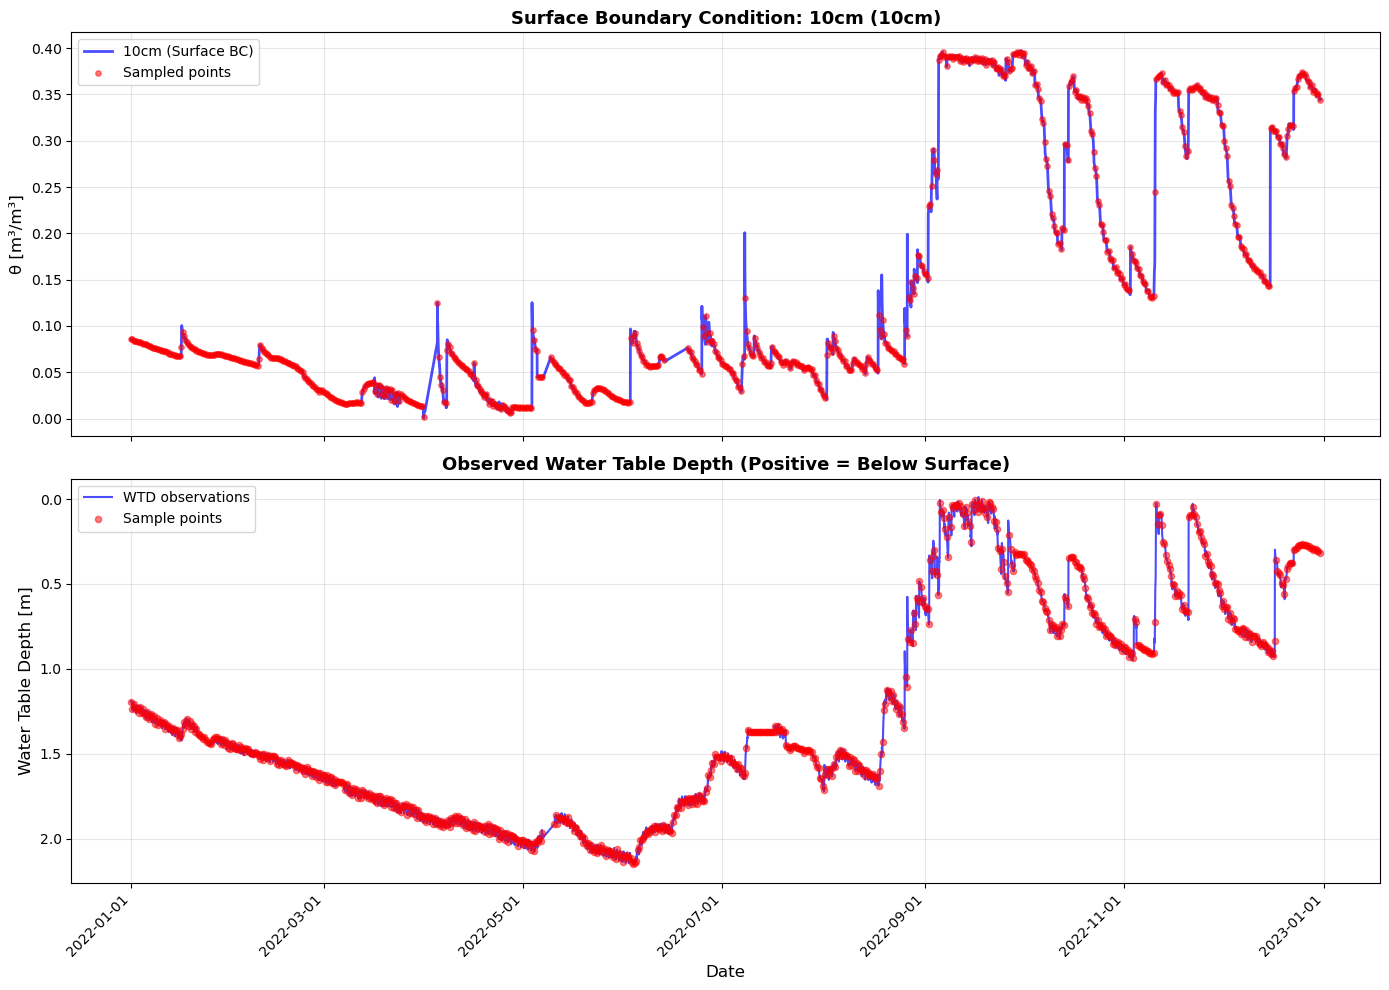

In [100]:
print('='*70)
print('SURFACE BC AND WATER TABLE DEPTH')
print('='*70)

bc_times, bc_values = dataset.get_bc_data()
bc_days = bc_times / 86400.0
bc_datetimes = [start_datetime + timedelta(seconds=float(t)) for t in bc_times]

surface_depth_name = dataset.obs_depths[0]
depth_cm = int(abs(obs_depths[0]) * 100)

wtd_data = dataset.get_wtd_data_for_viz()

# Create figure with 2 subplots (or 1 if no WTD)
if wtd_data is not None:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    
    # Top subplot: Surface BC
    ax1.plot(bc_datetimes, bc_values, 'b-', linewidth=2, alpha=0.7, label=f'{surface_depth_name} (Surface BC)')
    ax1.scatter(bc_datetimes[::20], bc_values[::20], color='red', s=15, alpha=0.5, 
              label='Sampled points', zorder=5)
    ax1.set_ylabel('θ [m³/m³]', fontsize=12)
    ax1.set_title(f'Surface Boundary Condition: {surface_depth_name} ({depth_cm}cm)', 
                 fontsize=13, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # Bottom subplot: WTD
    wtd_times = wtd_data['times']
    wtd_values = wtd_data['wtd']
    wtd_days = wtd_times / 86400.0
    wtd_datetimes = [start_datetime + timedelta(seconds=float(t)) for t in wtd_times]
    
    ax2.plot(wtd_datetimes, wtd_values, 'b-', linewidth=1.5, alpha=0.7, label='WTD observations')
    ax2.scatter(wtd_datetimes[::20], wtd_values[::20], color='red', s=20, 
              alpha=0.5, zorder=5, label='Sample points')
    
    ax2.set_xlabel('Date', fontsize=12)
    ax2.set_ylabel('Water Table Depth [m]', fontsize=12)
    ax2.set_title('Observed Water Table Depth (Positive = Below Surface)', 
                 fontsize=13, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.invert_yaxis()  # Invert so deeper WT is down
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    print(f'\n✓ Surface BC Information:')
    print(f'  Depth: {surface_depth_name} (first in config)')
    print(f'  Valid BC points: {len(bc_values)}')
    print(f'  θ range: {bc_values.min():.4f} - {bc_values.max():.4f} m³/m³')
    print(f'  Mean θ: {bc_values.mean():.4f} m³/m³')
    
    print(f'\n✓ WTD Data Available:')
    print(f'  Valid points: {len(wtd_values)}')
    print(f'  WTD range: {wtd_values.min():.3f} - {wtd_values.max():.3f} m')
    print(f'  Mean WTD: {wtd_values.mean():.3f} m')
    
else:
    # Only surface BC (no WTD)
    fig, ax1 = plt.subplots(figsize=(14, 5))
    ax1.plot(bc_datetimes, bc_values, 'b-', linewidth=2, alpha=0.7, label=f'{surface_depth_name} (Surface BC)')
    ax1.scatter(bc_datetimes[::20], bc_values[::20], color='red', s=15, alpha=0.5, 
              label='Sampled points', zorder=5)
    ax1.set_xlabel('Date', fontsize=12)
    ax1.set_ylabel('θ [m³/m³]', fontsize=12)
    ax1.set_title(f'Surface Boundary Condition: {surface_depth_name} ({depth_cm}cm)', 
                 fontsize=13, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    print(f'\n✓ Surface BC Information:')
    print(f'  Depth: {surface_depth_name} (first in config)')
    print(f'  Valid BC points: {len(bc_values)}')
    print(f'  θ range: {bc_values.min():.4f} - {bc_values.max():.4f} m³/m³')
    print(f'  Mean θ: {bc_values.mean():.4f} m³/m³')
    print(f'\n✗ No WTD data in this dataset')

plt.tight_layout()
plt.show()

In [101]:
print('='*70)
print('DATA QUALITY SUMMARY')
print('='*70)

print(f'\nDataset: {dataset.config.data_path}')
print(f'Date range: {dataset.config.start_date} to {dataset.config.end_date}')
print(f'Duration: {obs_times[-1]/86400:.1f} days')
print(f'Time points: {len(obs_times)}')

print(f'\nObservation Depths ({len(obs_depths)} total):')
print('  Depth  | Valid  | Missing | Completeness | θ Range')
print('  ' + '-'*60)

for i, (depth_name, z_obs, theta_obs) in enumerate(zip(dataset.obs_depths, obs_depths, obs_theta_series)):
    depth_cm = int(abs(z_obs) * 100)
    valid_mask = ~np.isnan(theta_obs)
    n_valid = np.sum(valid_mask)
    n_missing = len(theta_obs) - n_valid
    completeness = n_valid / len(theta_obs) * 100
    
    if n_valid > 0:
        theta_min = theta_obs[valid_mask].min()
        theta_max = theta_obs[valid_mask].max()
        range_str = f'{theta_min:.4f}-{theta_max:.4f}'
    else:
        range_str = 'No data'
    
    print(f'  {depth_cm:3d}cm | {n_valid:6d} | {n_missing:7d} | {completeness:11.1f}% | {range_str}')

if wtd_data is not None:
    wtd_valid_mask = ~np.isnan(wtd_values)
    n_wtd_valid = np.sum(wtd_valid_mask)
    n_wtd_missing = len(wtd_values) - n_wtd_valid
    wtd_completeness = n_wtd_valid / len(wtd_values) * 100
    
    print(f'\nWater Table Depth:')
    print(f'  Valid points: {n_wtd_valid} / {len(wtd_values)} ({wtd_completeness:.1f}%)')
    print(f'  Missing: {n_wtd_missing}')
    if n_wtd_valid > 0:
        print(f'  Range: {wtd_values[wtd_valid_mask].min():.3f} - {wtd_values[wtd_valid_mask].max():.3f} m')

print(f'\nBoundary Condition:')
print(f'  Type: {dataset.bc_type}')
print(f'  Surface depth: {dataset.obs_depths[0]} (first in config)')
print(f'  BC points: {len(bc_values)}')

print(f'\nInitial Condition:')
print(f'  Type: {dataset.ic_type}')
print(f'  Profile points: {len(dataset.ic_profile["depths"])}')

print('\n' + '='*70)
print('✓ DATA EXPLORATION COMPLETE')
print('='*70)
print('\nNext steps:')
print('  1. Ready for training with:')
print(f'     python hpc/train_simple.py --config {config_file.replace("../", "")}')
print('  2. Or use train_simple.ipynb for interactive training')
print('  3. Results will automatically include:')
print(f'     - θ validation at {len(obs_depths)} depths')
if wtd_data is not None:
    print(f'     - WTD validation ({len(wtd_values)} observations)')
print('='*70)

DATA QUALITY SUMMARY

Dataset: ../data/AMF_US-ONA_BASE_HH_4-5.csv
Date range: 2022-01-01 to 2022-12-31
Duration: 364.0 days
Time points: 17473

Observation Depths (2 total):
  Depth  | Valid  | Missing | Completeness | θ Range
  ------------------------------------------------------------
   10cm |  16852 |     621 |        96.4% | 0.0006-0.3972
   20cm |  16758 |     715 |        95.9% | 0.0048-0.4288

Water Table Depth:
  Valid points: 17313 / 17313 (100.0%)
  Missing: 0
  Range: -0.012 - 2.150 m

Boundary Condition:
  Type: dirichlet
  Surface depth: 10cm (first in config)
  BC points: 16852

Initial Condition:
  Type: obs
  Profile points: 2

✓ DATA EXPLORATION COMPLETE

Next steps:
  1. Ready for training with:
     python hpc/train_simple.py --config configs/us_ona_2022.yaml
  2. Or use train_simple.ipynb for interactive training
  3. Results will automatically include:
     - θ validation at 2 depths
     - WTD validation (17313 observations)


CALCULATING HYDRAULIC PROPERTIES FROM θ DATA

NORMALIZATION SCALES
Length scale (L):           3.000 m
Head scale (H_*):           3.000 m
Conductivity scale (K_*):   3.00e-06 m/s
Flux scale (Q_*):           3.00e-06 m/s
Water content span (θ_*):   0.480
Time scale (T):             4.80e+05 s (133.33 hours)
Dimensionless α̃:            3.0000
Dimensionless S̃_max:        0.1500


Soil Parameters (from YAML):
  theta_s: 0.6
  theta_r: 0.12
  alpha: 1.0
  n: 1.3
  Ks: 3e-06
  l: 0.5

Physics Parameters (from YAML):
  L (characteristic length): 3.0 m
  S_max (max sink): 1.5e-07 1/s

✓ Computed Se, h, K(h) for 2 depths


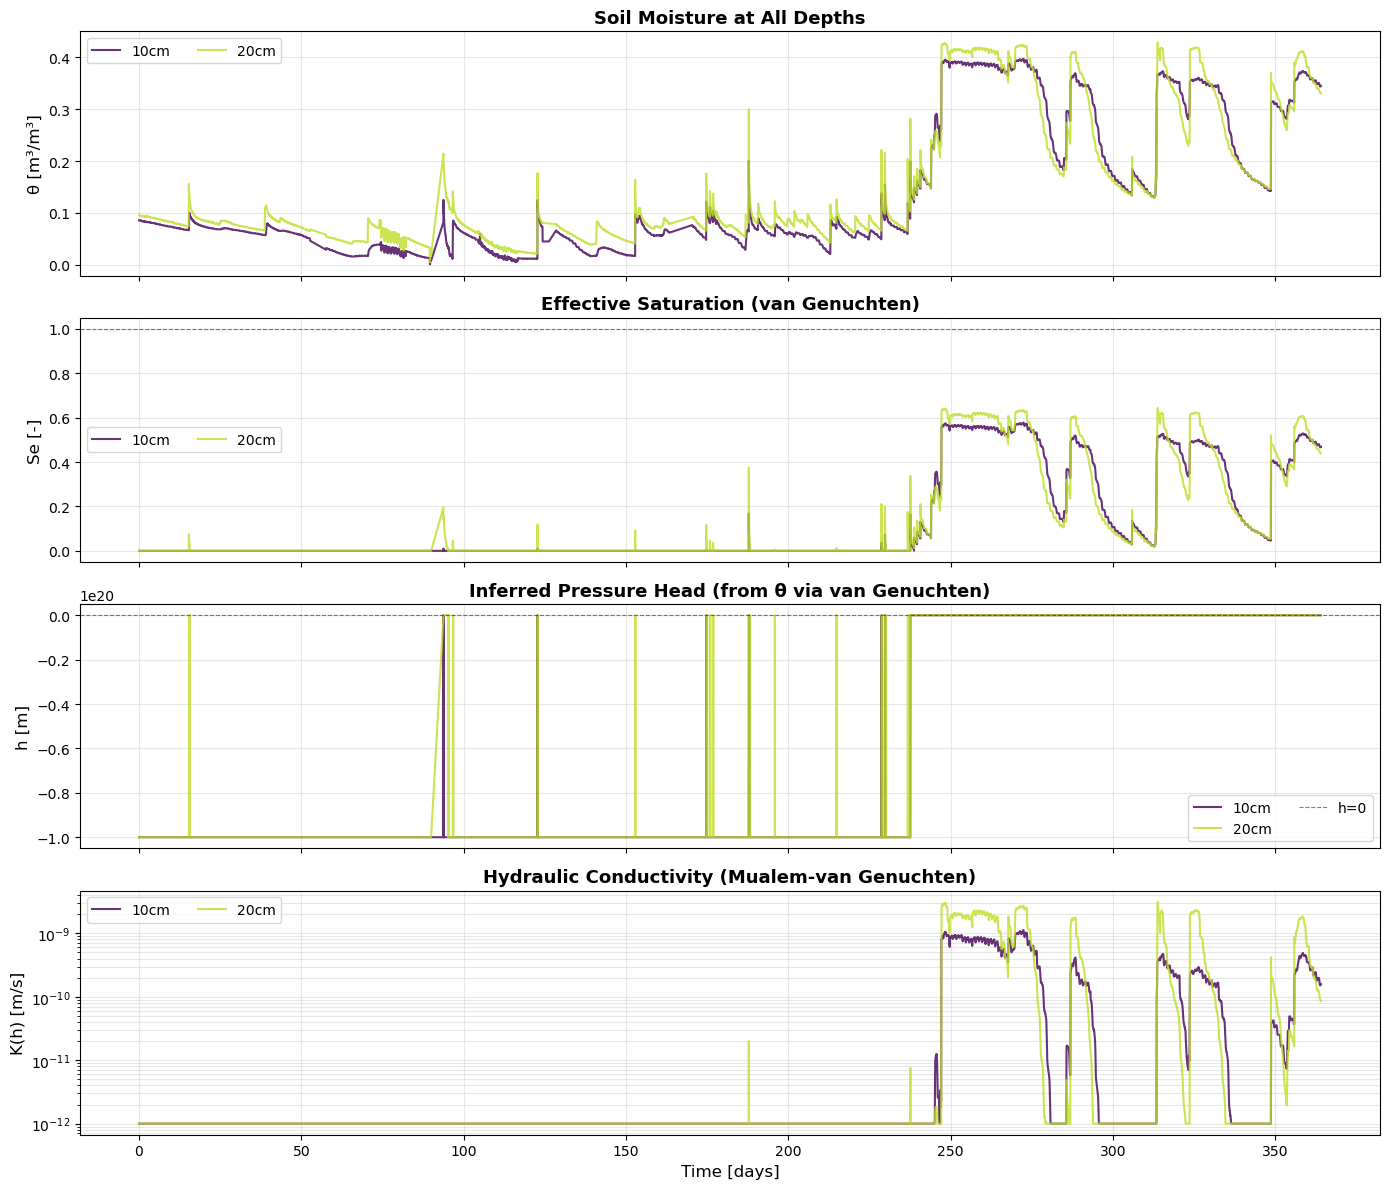


HYDRAULIC PROPERTY STATISTICS BY DEPTH

10cm:
  θ range:    0.0006 - 0.3972 m³/m³
  Se range:   0.0000 - 0.5775
  h range:    -100000257090785378304.0000 - -5.7857 m
  K range:    0.000e+00 - 1.122e-09 m/s
  Data points: 16852

20cm:
  θ range:    0.0048 - 0.4288 m³/m³
  Se range:   0.0000 - 0.6433
  h range:    -100000257090785378304.0000 - -3.8467 m
  K range:    0.000e+00 - 3.163e-09 m/s
  Data points: 16758


In [102]:
print('='*70)
print('CALCULATING HYDRAULIC PROPERTIES FROM θ DATA')
print('='*70)

from src.normalization_helper import NormalizationHelper
import torch

# Initialize normalization helper with soil parameters
normalizer = NormalizationHelper(
    dataset.soil_params, 
    L=dataset.L, 
    S_max=dataset.S_max
)

print(f'\nSoil Parameters (from YAML):')
for key, val in dataset.soil_params.items():
    print(f'  {key}: {val}')

print(f'\nPhysics Parameters (from YAML):')
print(f'  L (characteristic length): {dataset.L} m')
print(f'  S_max (max sink): {dataset.S_max} 1/s')

# Process all depths
all_results = {}
colors = plt.cm.viridis(np.linspace(0, 0.9, len(obs_depths)))

for i, (depth_name, z_obs, theta_obs) in enumerate(zip(dataset.obs_depths, obs_depths, obs_theta_series)):
    # Remove NaN values
    valid_mask = ~np.isnan(theta_obs)
    if not valid_mask.any():
        continue
    
    t_valid = obs_times[valid_mask]
    theta_valid = theta_obs[valid_mask]
    
    # Convert θ → Se (Effective Saturation)
    theta_r = normalizer.theta_r
    theta_star = normalizer.theta_star
    Se = np.clip((theta_valid - theta_r) / theta_star, 1e-6, 1.0 - 1e-6)
    
    # Convert Se → h (Pressure Head) using van Genuchten
    alpha_tilde = normalizer.alpha_tilde
    n_vg = normalizer.n
    m_vg = normalizer.m
    
    Se_t = torch.tensor(Se, dtype=torch.float32).view(-1, 1)
    with torch.no_grad():
        # Van Genuchten inverse: h = -[Se^(-1/m) - 1]^(1/n) / α
        inv_term = torch.pow(torch.clamp(Se_t, 1e-6, 1.0 - 1e-6), -1.0 / m_vg) - 1.0
        h_tilde = -torch.pow(torch.clamp(inv_term, min=0.0), 1.0 / n_vg) / float(alpha_tilde)
        
        # Handle saturated conditions (Se ≈ 1 → h ≈ 0)
        sat_mask = (Se_t >= 1.0 - 1e-6)
        h_tilde = torch.where(sat_mask, torch.zeros_like(h_tilde), h_tilde)
        
        # Denormalize to dimensional h
        h = normalizer.denormalize_h(h_tilde)
        
        # Calculate K(h) using Mualem model
        K_rel = normalizer.K_tilde(h_tilde)
        Ks = dataset.soil_params['Ks']
        K = K_rel * Ks
    
    # Store results
    t_days = t_valid / 86400.0
    all_results[depth_name] = {
        't_days': t_days,
        'theta': theta_valid,
        'Se': Se,
        'h': h.cpu().numpy().flatten(),
        'K': K.cpu().numpy().flatten(),
    }

print(f'\n✓ Computed Se, h, K(h) for {len(all_results)} depths')

# Create 4-panel plot
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# Panel 1: Soil Moisture θ
for i, depth_name in enumerate(all_results.keys()):
    data = all_results[depth_name]
    depth_cm = int(abs(dataset._depth_name_to_meters(depth_name)) * 100)
    axes[0].plot(data['t_days'], data['theta'], color=colors[i],
                label=f'{depth_cm}cm', linewidth=1.5, alpha=0.8)
axes[0].set_ylabel('θ [m³/m³]', fontsize=12)
axes[0].set_title('Soil Moisture at All Depths', fontsize=13, fontweight='bold')
axes[0].legend(ncol=min(3, len(all_results)), fontsize=10, loc='best')
axes[0].grid(True, alpha=0.3)

# Panel 2: Effective Saturation Se
for i, depth_name in enumerate(all_results.keys()):
    data = all_results[depth_name]
    depth_cm = int(abs(dataset._depth_name_to_meters(depth_name)) * 100)
    axes[1].plot(data['t_days'], data['Se'], color=colors[i],
                label=f'{depth_cm}cm', linewidth=1.5, alpha=0.8)
axes[1].set_ylabel('Se [-]', fontsize=12)
axes[1].set_title('Effective Saturation (van Genuchten)', fontsize=13, fontweight='bold')
axes[1].legend(ncol=min(3, len(all_results)), fontsize=10, loc='best')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(1.0, color='k', linewidth=0.8, alpha=0.5, linestyle='--', label='Saturated')

# Panel 3: Pressure Head h
for i, depth_name in enumerate(all_results.keys()):
    data = all_results[depth_name]
    depth_cm = int(abs(dataset._depth_name_to_meters(depth_name)) * 100)
    axes[2].plot(data['t_days'], data['h'], color=colors[i],
                label=f'{depth_cm}cm', linewidth=1.5, alpha=0.8)
axes[2].set_ylabel('h [m]', fontsize=12)
axes[2].set_title('Inferred Pressure Head (from θ via van Genuchten)', fontsize=13, fontweight='bold')
axes[2].axhline(0.0, color='k', linewidth=0.8, alpha=0.5, linestyle='--', label='h=0')
axes[2].legend(ncol=min(3, len(all_results)), fontsize=10, loc='best')
axes[2].grid(True, alpha=0.3)

# Panel 4: Hydraulic Conductivity K(h)
for i, depth_name in enumerate(all_results.keys()):
    data = all_results[depth_name]
    depth_cm = int(abs(dataset._depth_name_to_meters(depth_name)) * 100)
    axes[3].semilogy(data['t_days'], np.maximum(data['K'], 1e-12), color=colors[i],
                    label=f'{depth_cm}cm', linewidth=1.5, alpha=0.8)
axes[3].set_ylabel('K(h) [m/s]', fontsize=12)
axes[3].set_xlabel('Time [days]', fontsize=12)
axes[3].set_title('Hydraulic Conductivity (Mualem-van Genuchten)', fontsize=13, fontweight='bold')
axes[3].legend(ncol=min(3, len(all_results)), fontsize=10, loc='best')
axes[3].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print('\n' + '='*70)
print('HYDRAULIC PROPERTY STATISTICS BY DEPTH')
print('='*70)
for depth_name in all_results.keys():
    data = all_results[depth_name]
    depth_cm = int(abs(dataset._depth_name_to_meters(depth_name)) * 100)
    print(f'\n{depth_cm}cm:')
    print(f'  θ range:    {data["theta"].min():.4f} - {data["theta"].max():.4f} m³/m³')
    print(f'  Se range:   {data["Se"].min():.4f} - {data["Se"].max():.4f}')
    print(f'  h range:    {data["h"].min():.4f} - {data["h"].max():.4f} m')
    print(f'  K range:    {data["K"].min():.3e} - {data["K"].max():.3e} m/s')
    print(f'  Data points: {len(data["t_days"])}')
print('='*70)